# Quantitative Framework: snPATHOseq vs CosMx CNV Profiles

This notebook applies the same quantitative CNV validation framework to two already bin-aggregated profiles.


## Inputs


In [1]:
from pathlib import Path

snpatho_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/snpatho_tumor_cells_mean_cnv_per_bin.csv')
cosmx_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/cosmx_tumor_cells_mean_cnv_per_bin.csv')
sample_name = 'CRC'
truth_label = 'snPATHOseq'
pred_label = 'CosMx_tumor'

In [2]:
import sys
import pandas as pd

repo_root = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from insitucnv.tl.quantitative_validation import (
    build_binwise_profile_comparison_table,
    build_output_path,
    compute_validation_metrics,
    load_bin_cnv_values,
    plot_confusion_matrix,
    plot_profile_comparison,
    plot_profile_comparison_lines,
    plot_threshold_scatter,
    plot_truth_overlay,
    rename_threshold_columns,
    save_dataframe,
    select_validation_thresholds,
)

NOTEBOOK_DIR = repo_root / 'Colorectal_cancer_CosMxWTx/02_Compare'
output_dir = NOTEBOOK_DIR / 'results'
output_dir.mkdir(parents=True, exist_ok=True)


## Load Data


In [3]:
snpatho_rows = load_bin_cnv_values(snpatho_file)
cosmx_rows = load_bin_cnv_values(cosmx_file)
metric_df, axis = build_binwise_profile_comparison_table(
    truth_rows=snpatho_rows,
    pred_rows=cosmx_rows,
    truth_label=truth_label,
    pred_label=pred_label,
)

print('Loaded comparison inputs')
print('  snPATHOseq bins:', len(snpatho_rows))
print('  CosMx bins     :', len(cosmx_rows))
print('  shared bins    :', len(metric_df))
print('  output_dir     :', output_dir)

display(metric_df.head())


Loaded comparison inputs
  snPATHOseq bins: 1147
  CosMx bins     : 1147
  shared bins    : 1147
  output_dir     : /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results


,chromosome,chr_num,bin_index,truth_value,pred_value,x,truth_label,pred_label
0,chr1,1,0,0.009107,0.004445,0.0,snPATHOseq,CosMx_tumor
1,chr1,1,1,0.010062,0.003625,1.0,snPATHOseq,CosMx_tumor
2,chr1,1,2,0.008055,0.003111,2.0,snPATHOseq,CosMx_tumor
3,chr1,1,3,0.003611,0.002103,3.0,snPATHOseq,CosMx_tumor
4,chr1,1,4,0.001910,0.001825,4.0,snPATHOseq,CosMx_tumor


## Comparison Plots


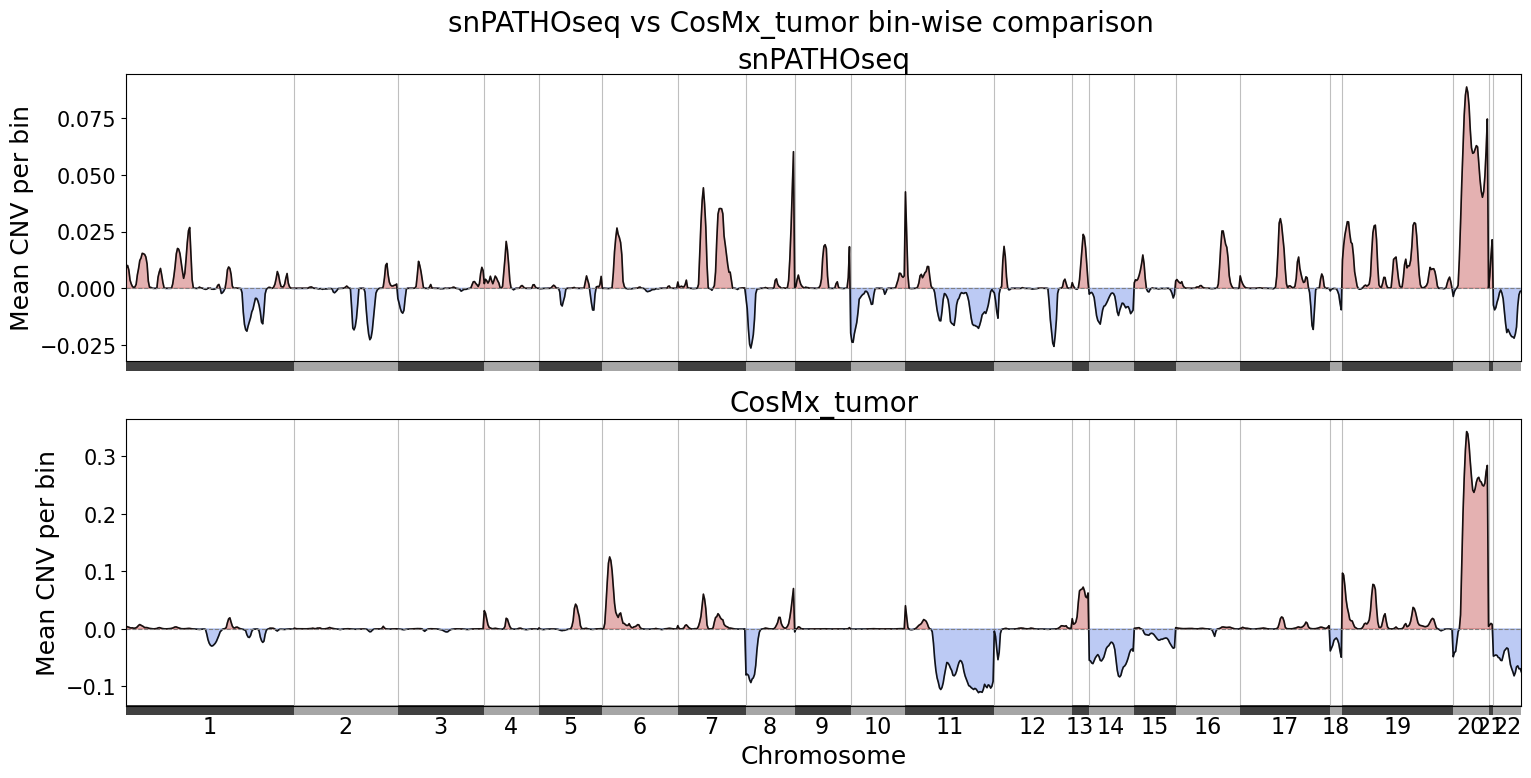

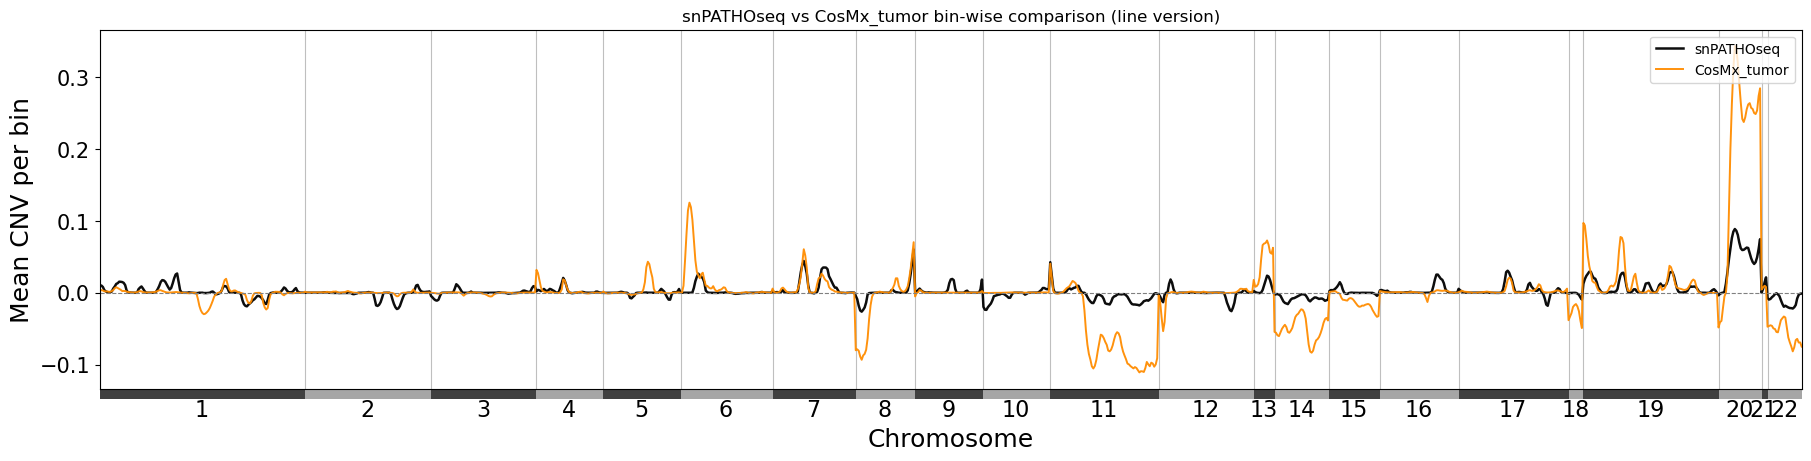

PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__comparison_plot_line.pdf')

In [4]:
plot_profile_comparison(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='truth_value',
    pred_col='pred_value',
    truth_label=truth_label,
    pred_label=pred_label,
    title=f'{truth_label} vs {pred_label} bin-wise comparison',
    ylabel='Mean CNV per bin',
    output_dir=output_dir,
    sample_name=sample_name,
)

plot_profile_comparison_lines(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='truth_value',
    pred_col='pred_value',
    truth_label=truth_label,
    pred_label=pred_label,
    title=f'{truth_label} vs {pred_label} bin-wise comparison (line version)',
    ylabel='Mean CNV per bin',
    output_dir=output_dir,
    sample_name=sample_name,
)


## Threshold Selection


In [5]:
truth_thr, pred_thr, truth_threshold_grid_df, pred_threshold_grid_df = select_validation_thresholds(
    metric_df=metric_df,
    truth_col='truth_value',
    pred_col='pred_value',
    truth_threshold_name='snpatho_threshold',
    pred_threshold_name='cosmx_threshold',
    truth_min_threshold=0.0001,
    pred_min_threshold=0.0001,
)

print('Selected thresholds')
print('  snPATHOseq threshold :', round(truth_thr, 6))
print('  CosMx threshold      :', round(pred_thr, 6))

display(truth_threshold_grid_df.head(10))
display(pred_threshold_grid_df.head(10))

save_dataframe(truth_threshold_grid_df, output_dir, sample_name, 'snpatho_threshold_auc_grid', index=False)
save_dataframe(pred_threshold_grid_df, output_dir, sample_name, 'cosmx_threshold_f1_grid', index=False)


Selected thresholds
  snPATHOseq threshold : 0.020151
  CosMx threshold      : 0.01843


,snpatho_threshold,auc_gain,auc_loss,auc_mean,n_truth_gain,n_truth_loss
0,0.020151,0.969501,0.860466,0.914984,71,16
1,0.020156,0.969501,0.860466,0.914984,71,16
2,0.020136,0.969948,0.858667,0.914308,72,17
3,0.020433,0.969625,0.853121,0.911373,70,15
4,0.020296,0.969501,0.853121,0.911311,71,15
5,0.020076,0.969948,0.850064,0.910006,72,18
6,0.020067,0.966238,0.850064,0.908151,73,18
7,0.021405,0.970234,0.844350,0.907292,68,11
8,0.021260,0.969536,0.844350,0.906943,69,11
9,0.021396,0.969536,0.844350,0.906943,69,11


,cosmx_threshold,f1_gain,f1_loss,f1_mean,accuracy_3class
0,0.018430,0.703030,0.105882,0.404456,0.824760
1,0.018656,0.703030,0.105882,0.404456,0.824760
2,0.020109,0.696203,0.109091,0.402647,0.829991
3,0.018168,0.698795,0.105263,0.402029,0.823017
4,0.018386,0.698795,0.105263,0.402029,0.823017
5,0.019395,0.695122,0.107784,0.401453,0.826504
6,0.017801,0.698225,0.104046,0.401136,0.820401
7,0.019259,0.695122,0.107143,0.401132,0.825632
8,0.019080,0.695122,0.106509,0.400815,0.824760
9,0.019214,0.695122,0.106509,0.400815,0.824760


PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__cosmx_threshold_f1_grid.csv')

## Metrics And Diagnostics


,sample_name,truth_label,pred_label,n_rows,snpatho_threshold,cosmx_threshold,auc_gain,auc_loss,auc_mean,precision_gain,precision_loss,precision_mean,recall_gain,recall_loss,recall_mean,f1_gain,f1_loss,f1_mean
0,CRC,snPATHOseq,CosMx_tumor,1147,0.020151,0.01843,0.969501,0.860466,0.914984,0.617021,0.058442,0.337731,0.816901,0.5625,0.689701,0.70303,0.105882,0.404456


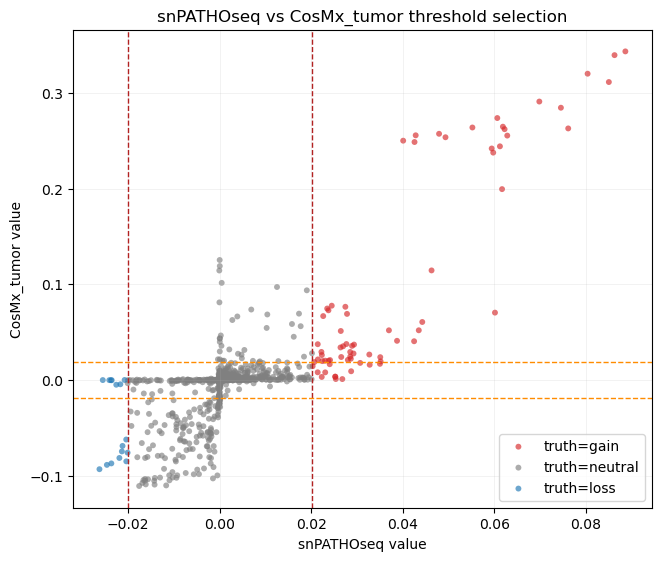

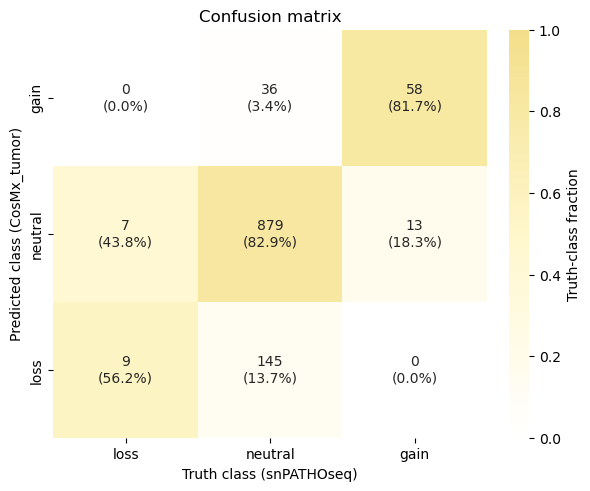

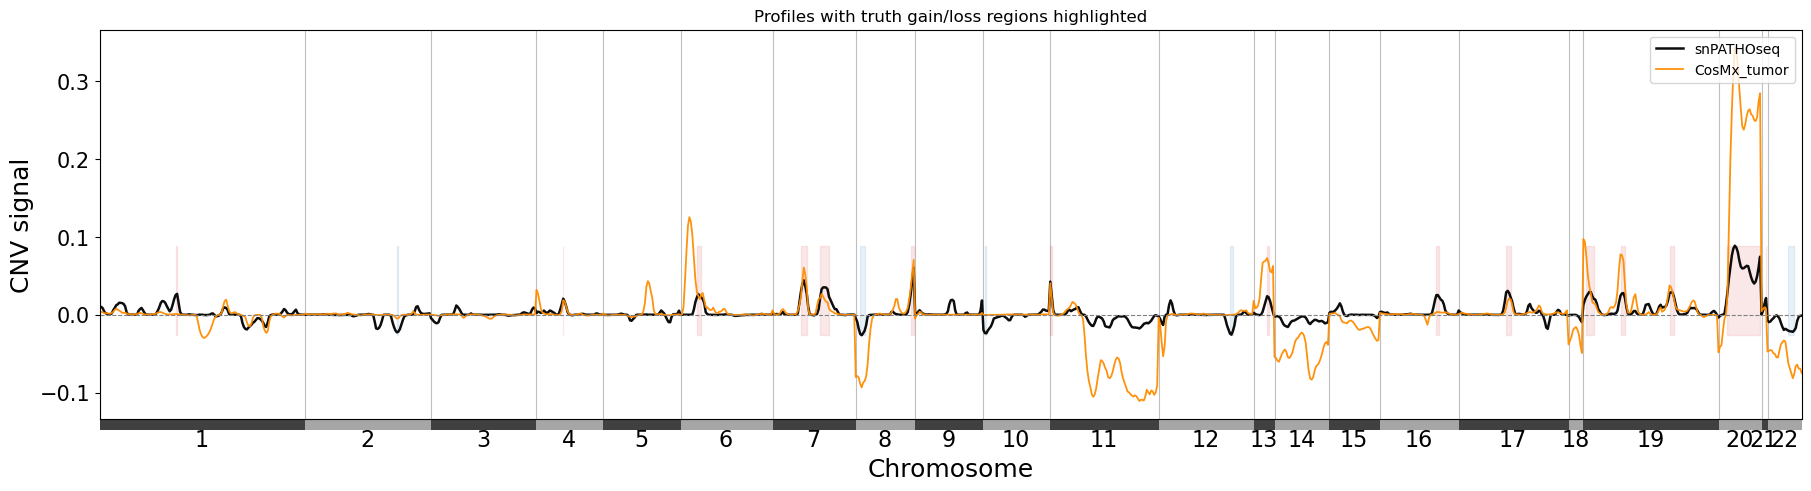

Saved:
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__comparison_plot.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__comparison_plot_line.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__threshold_scatter.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__confusion_matrix.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__truth_overlay.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__metrics_summary.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/02_Compare/results/CRC__comparison_rows.csv


In [6]:
metrics_df, truth_labels, pred_labels = compute_validation_metrics(
    metric_df=metric_df,
    truth_thr=truth_thr,
    pred_thr=pred_thr,
    truth_col='truth_value',
    pred_col='pred_value',
    metadata={
        'sample_name': sample_name,
        'truth_label': truth_label,
        'pred_label': pred_label,
    },
)
metrics_df = rename_threshold_columns(metrics_df, 'snpatho_threshold', 'cosmx_threshold')
metric_df = metric_df.copy()
metric_df['truth'] = truth_labels
metric_df['pred'] = pred_labels

display(metrics_df)
save_dataframe(metrics_df, output_dir, sample_name, 'metrics_summary', index=False)
save_dataframe(metric_df, output_dir, sample_name, 'comparison_rows', index=False)

plot_threshold_scatter(
    metric_df=metric_df,
    truth_labels=truth_labels,
    truth_thr=truth_thr,
    pred_thr=pred_thr,
    truth_col='truth_value',
    pred_col='pred_value',
    truth_label=truth_label,
    pred_label=pred_label,
    output_dir=output_dir,
    sample_name=sample_name,
)

cm_counts_df, cm_pct_df = plot_confusion_matrix(
    truth_labels=truth_labels,
    pred_labels=pred_labels,
    truth_label=truth_label,
    pred_label=pred_label,
    output_dir=output_dir,
    sample_name=sample_name,
)

plot_truth_overlay(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='truth_value',
    pred_col='pred_value',
    truth_label=truth_label,
    pred_label=pred_label,
    output_dir=output_dir,
    sample_name=sample_name,
)

save_dataframe(cm_counts_df.reset_index().rename(columns={'index': 'truth'}), output_dir, sample_name, 'confusion_matrix_counts', index=False)
save_dataframe(cm_pct_df.reset_index().rename(columns={'index': 'truth'}), output_dir, sample_name, 'confusion_matrix_row_pct', index=False)

print('Saved:')
for stem, suffix in [
    ('comparison_plot', '.pdf'),
    ('comparison_plot_line', '.pdf'),
    ('threshold_scatter', '.pdf'),
    ('confusion_matrix', '.pdf'),
    ('truth_overlay', '.pdf'),
    ('metrics_summary', '.csv'),
    ('comparison_rows', '.csv'),
]:
    print(' ', build_output_path(output_dir, sample_name, stem, suffix))
